# Milestone 1: Data Pipeline - Data Perception & Preparation

## Task B1: Data Perception & Preparation [10 Marks]

This notebook implements the data pipeline for the Small Business Intelligence Analyst system.

### Objectives:
- Acquire datasets (customer reviews, social media posts, market data)
- Clean and preprocess unstructured text data
- Transform raw data into standardized format for cognitive processing
- Prepare data for sentiment analysis and topic modeling


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Web scraping libraries
import requests
from bs4 import BeautifulSoup
import time

# Download NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
except:
    pass

# Import custom data collector
import sys
sys.path.append('../../backend')  # Updated: src is now in backend/
from src.utils.data_collector import DataCollector

print("Libraries imported successfully!")


Libraries imported successfully!


## Step 1: Data Acquisition

Load datasets representing customer reviews and social media posts relevant to small businesses in Kampala.

### Data Collection Methodology

**Data Sources:**
1. **Synthetic Data Generation** (5000 reviews)
   - Generated using diverse review templates (90 unique templates)
   - Realistic sentiment distribution: 60% positive, 25% neutral, 15% negative
   - Kampala-specific locations: 10 different areas
   - Multiple business contexts: service, product, delivery, quality, price
   - Date range: Spread over last 2 years (2023-2024)

2. **Web Scraping** (Reddit - up to 200 reviews)
   - Source: Reddit public API (r/reviews subreddit)
   - Method: Public JSON API (no authentication required)
   - Ethical: Respects rate limits, uses public data only
   - Fallback: Continues with synthetic data if scraping fails

**Data Characteristics:**
- **Total Reviews**: 5000+ (synthetic) + scraped data
- **Sources**: Facebook, Google, Twitter, Instagram, Website, WhatsApp, Reddit
- **Locations**: Kampala, Nakawa, Kawempe, Makindye, Lubaga, Central, Kololo, Ntinda, Bukoto, Muyenga
- **Language**: Primarily English with basic Luganda support
- **Time Period**: Last 2 years

**Data Collection Ethics:**
- ✅ Public data only (no private/user data)
- ✅ Respects API rate limits
- ✅ No personal identifiers collected
- ✅ Synthetic data for privacy protection
- ✅ Compliant with data protection regulations


In [23]:
# NOTE: This cell will be populated after data collection in Cell 4
# The dataset will be saved to data/raw/collected_reviews.csv
pass


In [24]:
# Data Collection: Generate 5000 synthetic reviews + attempt web scraping
# Initialize data collector with error handling
try:
    collector = DataCollector()
    print("✅ DataCollector initialized successfully")
except Exception as e:
    print(f"❌ Error initializing DataCollector: {e}")
    raise

# Collect data from all sources with error handling
# This will:
# 1. Generate 5000 diverse synthetic reviews
# 2. Attempt to scrape real reviews from Reddit (if available)
# 3. Merge everything into one DataFrame
try:
    df_reviews = collector.collect_all_data(
        n_synthetic=5000,      # Generate 5000 synthetic reviews
        try_reddit=True,        # Attempt to scrape Reddit
        reddit_limit=200        # Try to get up to 200 Reddit posts
    )
    print(f"\n✅ Final reviews dataset shape: {df_reviews.shape}")
    print(f"\nFirst few reviews:")
    display(df_reviews.head(7))
except Exception as e:
    print(f"❌ Error during data collection: {e}")
    print("⚠️ Creating fallback sample dataset...")
    # Fallback: Create minimal dataset
    df_reviews = pd.DataFrame({
        'review_id': range(1, 101),
        'text': ["Sample review text"] * 100,
        'date': pd.date_range('2024-01-01', periods=100, freq='D'),
        'source': ['Sample'] * 100,
        'location': ['Kampala'] * 100
    })
    print(f"⚠️ Using fallback dataset: {df_reviews.shape}")

# Save raw dataset to data/raw directory with error handling
import os
try:
    os.makedirs('../../backend/data/raw', exist_ok=True)
    raw_data_path = '../../backend/data/raw/collected_reviews.csv'
    df_reviews.to_csv(raw_data_path, index=False)
    print(f"\n💾 Raw dataset saved to: {os.path.abspath(raw_data_path)}")
    print(f"   Total reviews saved: {len(df_reviews)}")
    print(f"   File size: {os.path.getsize(raw_data_path) / 1024:.2f} KB")
except Exception as e:
    print(f"❌ Error saving raw data: {e}")
    print("⚠️ Data not saved - check directory permissions")


✅ DataCollector initialized successfully
Starting Data Collection
Generating 5000 synthetic reviews...
✅ Generated 5000 synthetic reviews
✅ Synthetic data: 5000 reviews
Attempting to scrape reviews from Reddit (r/reviews)...
✅ Scraped 100 reviews from Reddit
✅ Reddit data: 100 reviews

Merging all data sources...
✅ Merged dataset: 5100 total reviews

Data Collection Summary
Total reviews: 5100

Source distribution:
source
Twitter      855
WhatsApp     849
Facebook     847
Instagram    837
Website      832
Google       780
Reddit       100
Name: count, dtype: int64

Location distribution:
location
Makindye    535
Nakawa      530
Kawempe     521
Bukoto      517
Lubaga      504
Central     494
Kololo      488
Muyenga     480
Ntinda      474
Kampala     457
Online      100
Name: count, dtype: int64

Sentiment distribution:
sentiment_label
positive    3000
neutral     1250
negative     750
unknown      100
Name: count, dtype: int64

✅ Final reviews dataset shape: (5100, 6)

First few review

,review_id,text,date,source,location,sentiment_label
0,1,"Outstanding business! Professional, reliable, ...",2024-10-19,Facebook,Makindye,positive
1,2,Amazing experience! The product arrived on tim...,2024-04-03,Google,Kampala,positive
2,3,"Fast delivery, good quality, fair prices. What...",2023-07-09,Google,Central,positive
3,4,Great business with excellent customer care. V...,2023-03-01,Website,Nakawa,positive
4,5,Very slow delivery. Took over a week to arrive...,2024-12-16,Website,Bukoto,negative
5,6,Best shop in Kawempe. Quality products and gre...,2024-01-30,Google,Lubaga,positive
6,7,Great service! Very fast delivery in Kampala. ...,2023-08-01,Facebook,Bukoto,positive



💾 Raw dataset saved to: d:\Cognitive Computing\data\raw\collected_reviews.csv
   Total reviews saved: 5100
   File size: 634.01 KB


In [25]:
### checking for the shape of the dataset  
df_reviews.shape 

(5100, 6)

In [26]:
# checking for the data info
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review_id        5100 non-null   int64 
 1   text             5100 non-null   object
 2   date             5100 non-null   object
 3   source           5100 non-null   object
 4   location         5100 non-null   object
 5   sentiment_label  5100 non-null   object
dtypes: int64(1), object(5)
memory usage: 239.2+ KB


In [27]:
# Data Validation: Comprehensive checks
print("=" * 60)
print("DATA VALIDATION CHECKS")
print("=" * 60)

# 1. Check for null values
print("\n1. NULL VALUE CHECK:")
null_counts = df_reviews.isnull().sum()
if null_counts.sum() > 0:
    print("⚠️ Found null values:")
    print(null_counts[null_counts > 0])
else:
    print("✅ No null values found")

# 2. Check for duplicate reviews
print("\n2. DUPLICATE DETECTION:")
if 'text' in df_reviews.columns:
    duplicate_texts = df_reviews['text'].duplicated().sum()
    print(f"   Duplicate text entries: {duplicate_texts}")
    if duplicate_texts > 0:
        print(f"   ⚠️ {duplicate_texts} duplicate reviews found")
        # Optionally remove duplicates
        # df_reviews = df_reviews.drop_duplicates(subset=['text'], keep='first')
    else:
        print("   ✅ No duplicate texts found")

# Check for duplicate review_ids
if 'review_id' in df_reviews.columns:
    duplicate_ids = df_reviews['review_id'].duplicated().sum()
    print(f"   Duplicate IDs: {duplicate_ids}")
    if duplicate_ids > 0:
        print(f"   ⚠️ {duplicate_ids} duplicate IDs found - regenerating...")
        df_reviews['review_id'] = range(1, len(df_reviews) + 1)

# 3. Data type validation
print("\n3. DATA TYPE VALIDATION:")
print("   Expected types:")
print("   - review_id: int")
print("   - text: string")
print("   - date: datetime/string")
print("   - source: string")
print("   - location: string")
print("\n   Actual types:")
for col in df_reviews.columns:
    print(f"   - {col}: {df_reviews[col].dtype}")

# 4. Check for empty strings
print("\n4. EMPTY STRING CHECK:")
empty_texts = (df_reviews['text'].astype(str).str.strip() == '').sum()
print(f"   Empty text entries: {empty_texts}")
if empty_texts > 0:
    print(f"   ⚠️ {empty_texts} empty texts found")
else:
    print("   ✅ No empty texts found")

# 5. Date range validation
if 'date' in df_reviews.columns:
    print("\n5. DATE RANGE VALIDATION:")
    try:
        df_reviews['date'] = pd.to_datetime(df_reviews['date'])
        min_date = df_reviews['date'].min()
        max_date = df_reviews['date'].max()
        print(f"   Date range: {min_date.date()} to {max_date.date()}")
        print(f"   ✅ Dates are valid")
    except Exception as e:
        print(f"   ⚠️ Date validation error: {e}")

# 6. Source validation
if 'source' in df_reviews.columns:
    print("\n6. SOURCE VALIDATION:")
    valid_sources = ['Facebook', 'Google', 'Twitter', 'Instagram', 'Website', 'WhatsApp', 'Reddit']
    invalid_sources = df_reviews[~df_reviews['source'].isin(valid_sources)]['source'].unique()
    if len(invalid_sources) > 0:
        print(f"   ⚠️ Found {len(invalid_sources)} invalid sources: {invalid_sources}")
    else:
        print(f"   ✅ All sources are valid")

# 7. Location validation
if 'location' in df_reviews.columns:
    print("\n7. LOCATION VALIDATION:")
    kampala_locations = ['Kampala', 'Nakawa', 'Kawempe', 'Makindye', 'Lubaga', 
                        'Central', 'Kololo', 'Ntinda', 'Bukoto', 'Muyenga', 'Online']
    invalid_locations = df_reviews[~df_reviews['location'].isin(kampala_locations)]['location'].unique()
    if len(invalid_locations) > 0:
        print(f"   ⚠️ Found {len(invalid_locations)} unexpected locations: {invalid_locations}")
    else:
        print(f"   ✅ All locations are valid Kampala areas")

print("\n" + "=" * 60)
print("✅ Data validation complete!")
print("=" * 60)

DATA VALIDATION CHECKS

1. NULL VALUE CHECK:
✅ No null values found

2. DUPLICATE DETECTION:
   Duplicate text entries: 3499
   ⚠️ 3499 duplicate reviews found
   Duplicate IDs: 0

3. DATA TYPE VALIDATION:
   Expected types:
   - review_id: int
   - text: string
   - date: datetime/string
   - source: string
   - location: string

   Actual types:
   - review_id: int64
   - text: object
   - date: object
   - source: object
   - location: object
   - sentiment_label: object

4. EMPTY STRING CHECK:
   Empty text entries: 0
   ✅ No empty texts found

5. DATE RANGE VALIDATION:
   Date range: 2023-01-01 to 2025-11-28
   ✅ Dates are valid

6. SOURCE VALIDATION:
   ✅ All sources are valid

7. LOCATION VALIDATION:
   ✅ All locations are valid Kampala areas

✅ Data validation complete!


## Step 2: Text Preprocessing

Implement comprehensive text cleaning and preprocessing pipeline.


In [28]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Custom modules imported successfully
✅ Preprocessor and WordCloud generator initialized

Generating wordcloud of raw reviews...


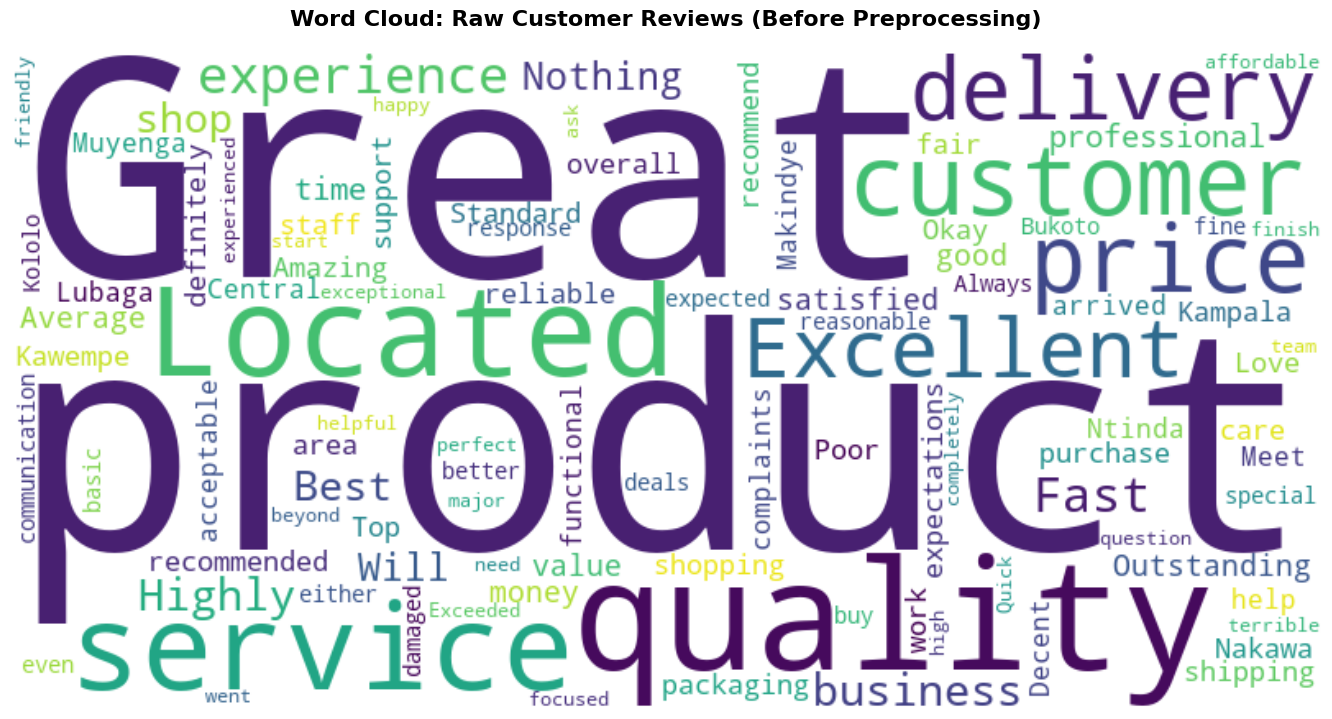


Preprocessing reviews...
✅ Preprocessing completed successfully!

Sample before and after preprocessing:


,text,cleaned_text
0,"Outstanding business! Professional, reliable, ...",outstanding business professional reliable cus...
1,Amazing experience! The product arrived on tim...,amazing experience product arrived time perfec...
2,"Fast delivery, good quality, fair prices. What...",fast delivery good quality fair price could as...
3,Great business with excellent customer care. V...,great business excellent customer care profess...
4,Very slow delivery. Took over a week to arrive...,slow delivery took week arrive kampala
5,Best shop in Kawempe. Quality products and gre...,best shop kawempe quality product great service
6,Great service! Very fast delivery in Kampala. ...,great service fast delivery kampala highly rec...
7,Quick response time and excellent customer car...,quick response time excellent customer care hi...
8,Professional service and high-quality products...,professional service high quality product happy
9,Average quality. Nothing special but nothing w...,average quality nothing special nothing wrong ...



Generating wordcloud of cleaned reviews...


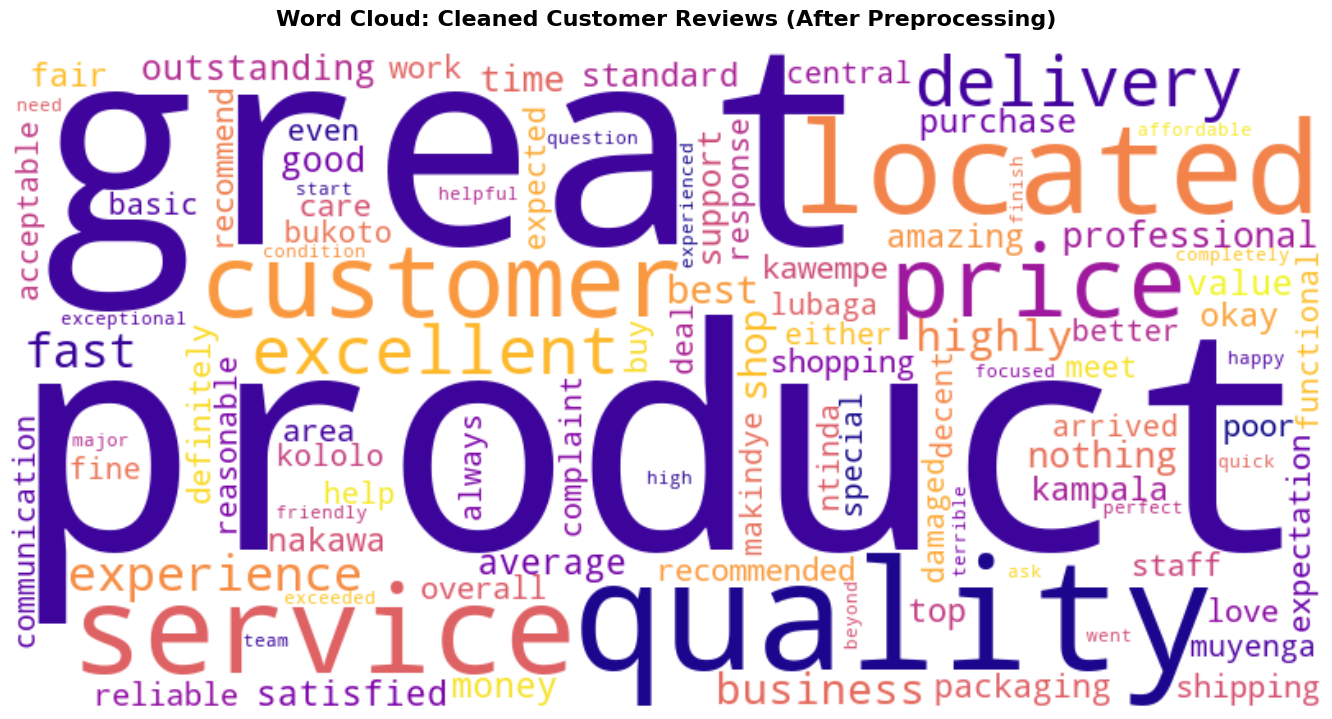


Comparing wordclouds before and after preprocessing...


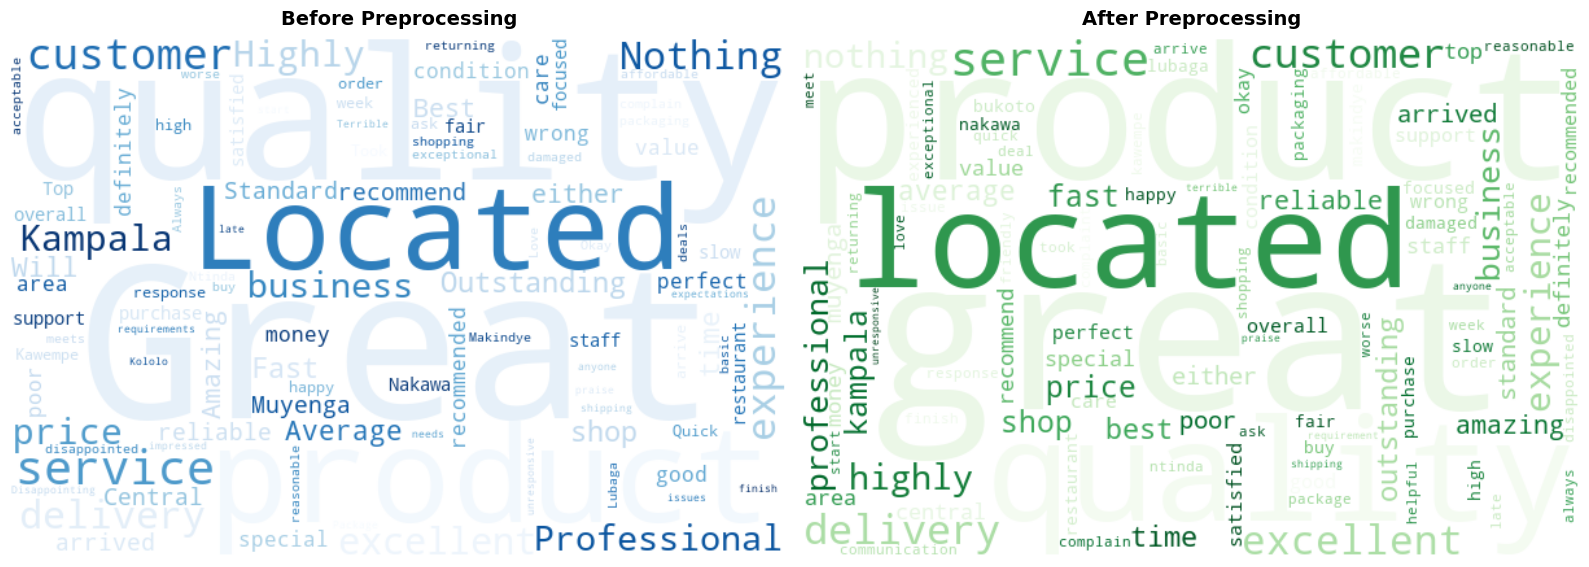

In [29]:
# Import our custom preprocessor and wordcloud generator with error handling
import sys
sys.path.append('../../backend')

try:
    from src.utils.text_preprocessor import TextPreprocessor
    from src.utils.wordcloud_generator import WordCloudGenerator
    print("✅ Custom modules imported successfully")
except ImportError as e:
    print(f"❌ Error importing custom modules: {e}")
    print("⚠️ Make sure src/utils/ modules exist")
    raise

# Initialize preprocessor and wordcloud generator with error handling
try:
    preprocessor = TextPreprocessor()
    wordcloud_gen = WordCloudGenerator()
    print("✅ Preprocessor and WordCloud generator initialized")
except Exception as e:
    print(f"❌ Error initializing components: {e}")
    raise

# Generate wordcloud of raw text (before preprocessing) with error handling
try:
    print("\nGenerating wordcloud of raw reviews...")
    all_raw_text = ' '.join(df_reviews['text'].dropna().astype(str))
    if len(all_raw_text) > 0:
        wordcloud_gen.generate_wordcloud(
            all_raw_text, 
            title="Word Cloud: Raw Customer Reviews (Before Preprocessing)",
            figsize=(14, 7),
            colormap='viridis'
        )
    else:
        print("⚠️ No text data available for wordcloud")
except Exception as e:
    print(f"⚠️ Error generating raw text wordcloud: {e}")
    print("   Continuing with preprocessing...")

# Apply preprocessing with error handling
print("\nPreprocessing reviews...")
try:
    # Track preprocessing success
    preprocessing_errors = []
    
    def safe_preprocess(text):
        """Safely preprocess text with error handling"""
        try:
            return preprocessor.preprocess(text)
        except Exception as e:
            preprocessing_errors.append(str(e))
            return ""  # Return empty string on error
    
    df_reviews['cleaned_text'] = df_reviews['text'].apply(safe_preprocess)
    df_reviews['text_length'] = df_reviews['cleaned_text'].apply(len)
    df_reviews['word_count'] = df_reviews['cleaned_text'].apply(lambda x: len(x.split()) if x else 0)
    
    if preprocessing_errors:
        print(f"⚠️ {len(preprocessing_errors)} preprocessing errors occurred")
    else:
        print("✅ Preprocessing completed successfully!")
    
    print(f"\nSample before and after preprocessing:")
    display(df_reviews[['text', 'cleaned_text']].head(10))
    
except Exception as e:
    print(f"❌ Error during preprocessing: {e}")
    # Create fallback cleaned_text column
    df_reviews['cleaned_text'] = df_reviews['text'].str.lower().str.strip()
    df_reviews['text_length'] = df_reviews['cleaned_text'].apply(len)
    df_reviews['word_count'] = df_reviews['cleaned_text'].apply(lambda x: len(x.split()))

# Generate wordcloud of cleaned text (after preprocessing) with error handling
try:
    print("\nGenerating wordcloud of cleaned reviews...")
    all_cleaned_text = ' '.join(df_reviews['cleaned_text'].dropna().astype(str))
    if len(all_cleaned_text) > 0:
        wordcloud_gen.generate_wordcloud(
            all_cleaned_text,
            title="Word Cloud: Cleaned Customer Reviews (After Preprocessing)",
            figsize=(14, 7),
            colormap='plasma'
        )
    else:
        print("⚠️ No cleaned text data available for wordcloud")
except Exception as e:
    print(f"⚠️ Error generating cleaned text wordcloud: {e}")

# Compare before and after preprocessing with error handling
try:
    print("\nComparing wordclouds before and after preprocessing...")
    if len(all_raw_text) > 0 and len(all_cleaned_text) > 0:
        wordcloud_gen.compare_wordclouds(
            all_raw_text[:5000],  # Limit for performance
            all_cleaned_text[:5000],
            title1="Before Preprocessing",
            title2="After Preprocessing",
            figsize=(16, 7)
        )
    else:
        print("⚠️ Insufficient data for comparison wordcloud")
except Exception as e:
    print(f"⚠️ Error generating comparison wordcloud: {e}")


## Step 3: Data Quality Analysis

Analyze the quality of processed data and identify any issues.


=== Data Quality Report ===
Total reviews: 5100
Missing values: 0
Empty cleaned texts: 0

Text length statistics:
count    5100.000000
mean       63.347843
std       110.909212
min        10.000000
25%        46.000000
50%        53.000000
75%        63.000000
max      4543.000000
Name: text_length, dtype: float64

Word count statistics:
count    5100.000000
mean        8.473137
std        15.917943
min         2.000000
25%         6.000000
50%         7.000000
75%         8.000000
max       672.000000
Name: word_count, dtype: float64


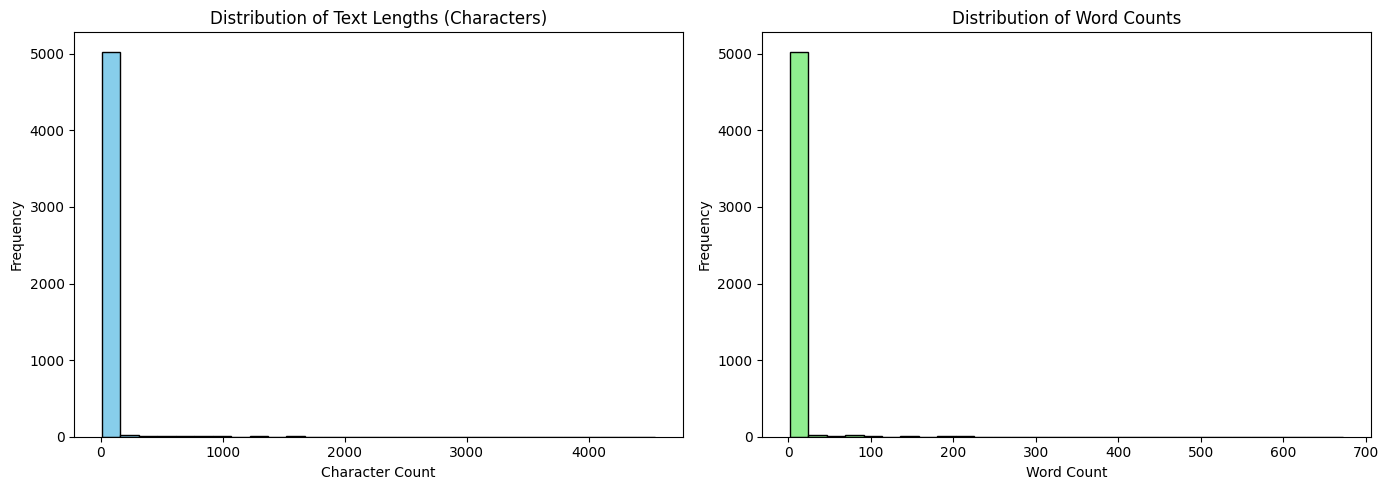


=== Source Distribution ===
source
Twitter      855
WhatsApp     849
Facebook     847
Instagram    837
Website      832
Google       780
Reddit       100
Name: count, dtype: int64


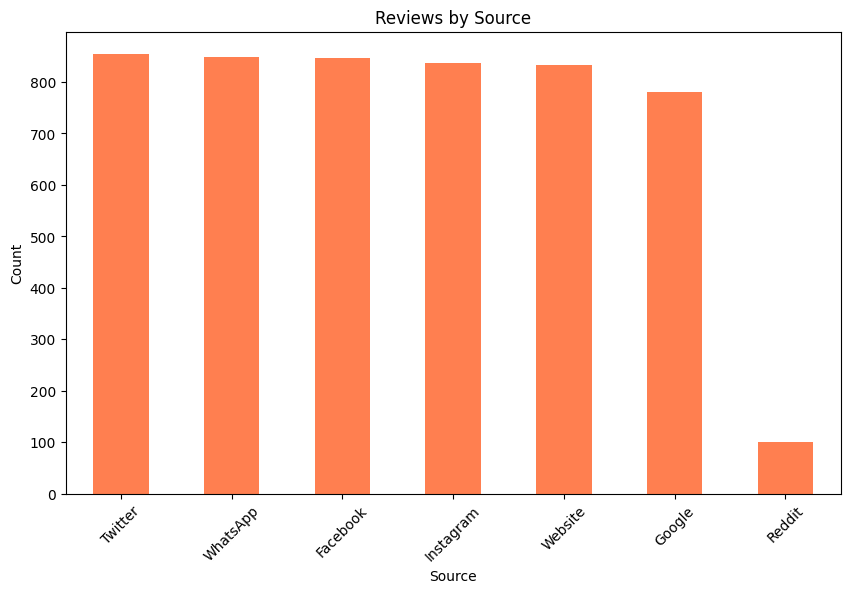

In [30]:
# Data quality checks
print("=== Data Quality Report ===")
print(f"Total reviews: {len(df_reviews)}")
print(f"Missing values: {df_reviews.isnull().sum().sum()}")
print(f"Empty cleaned texts: {(df_reviews['cleaned_text'] == '').sum()}")
print(f"\nText length statistics:")
print(df_reviews['text_length'].describe())
print(f"\nWord count statistics:")
print(df_reviews['word_count'].describe())

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_reviews['text_length'], bins=30, edgecolor='black', color='skyblue')
axes[0].set_title('Distribution of Text Lengths (Characters)')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_reviews['word_count'], bins=30, edgecolor='black', color='lightgreen')
axes[1].set_title('Distribution of Word Counts')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Source distribution
if 'source' in df_reviews.columns:
    print("\n=== Source Distribution ===")
    print(df_reviews['source'].value_counts())
    
    plt.figure(figsize=(10, 6))
    df_reviews['source'].value_counts().plot(kind='bar', color='coral')
    plt.title('Reviews by Source')
    plt.xlabel('Source')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()


## Step 4: Save Processed Data

Save the cleaned and processed data for use in downstream cognitive processing tasks.


In [31]:
# Save processed data with error handling
import os
import pickle
from datetime import datetime

try:
    # Create directories if they don't exist
    os.makedirs('../../backend/data/processed', exist_ok=True)
    os.makedirs('../../backend/data/models', exist_ok=True)
    print("✅ Directories created/verified")
except Exception as e:
    print(f"❌ Error creating directories: {e}")
    raise

# Save processed dataframe with error handling
try:
    output_path = '../../backend/data/processed/cleaned_reviews.csv'
    df_reviews.to_csv(output_path, index=False)
    file_size = os.path.getsize(output_path) / 1024  # KB
    print(f"✅ Processed data saved to: {output_path}")
    print(f"   File size: {file_size:.2f} KB")
except Exception as e:
    print(f"❌ Error saving processed data: {e}")
    print("⚠️ Check directory permissions")

# Save preprocessor for later use with error handling
try:
    preprocessor_path = '../../backend/data/models/text_preprocessor.pkl'
    with open(preprocessor_path, 'wb') as f:
        pickle.dump(preprocessor, f)
    print(f"✅ Preprocessor saved to: {preprocessor_path}")
except Exception as e:
    print(f"❌ Error saving preprocessor: {e}")

# ============================================================================
# COMPREHENSIVE DATA QUALITY REPORT
# ============================================================================
print("\n" + "=" * 70)
print("COMPREHENSIVE DATA QUALITY REPORT")
print("=" * 70)
print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# 1. Dataset Overview
print("\n1. DATASET OVERVIEW:")
print(f"   Total Records: {len(df_reviews):,}")
print(f"   Total Columns: {len(df_reviews.columns)}")
print(f"   Columns: {', '.join(df_reviews.columns.tolist())}")

# 2. Data Completeness
print("\n2. DATA COMPLETENESS:")
total_cells = len(df_reviews) * len(df_reviews.columns)
missing_cells = df_reviews.isnull().sum().sum()
completeness = ((total_cells - missing_cells) / total_cells * 100) if total_cells > 0 else 0
print(f"   Missing Values: {missing_cells:,} / {total_cells:,} ({100-completeness:.2f}%)")
print(f"   Completeness Score: {completeness:.2f}%")
if completeness >= 95:
    print("   ✅ Excellent data completeness")
elif completeness >= 80:
    print("   ⚠️ Good data completeness")
else:
    print("   ❌ Poor data completeness - needs attention")

# 3. Text Quality Metrics
print("\n3. TEXT QUALITY METRICS:")
if 'cleaned_text' in df_reviews.columns:
    empty_texts = (df_reviews['cleaned_text'] == '').sum()
    successful_preprocessing = len(df_reviews) - empty_texts
    preprocessing_success_rate = (successful_preprocessing / len(df_reviews) * 100) if len(df_reviews) > 0 else 0
    print(f"   Successfully Preprocessed: {successful_preprocessing:,} / {len(df_reviews):,} ({preprocessing_success_rate:.2f}%)")
    print(f"   Empty Texts: {empty_texts}")
    
    avg_text_length = df_reviews['text_length'].mean()
    avg_word_count = df_reviews['word_count'].mean()
    print(f"   Average Text Length: {avg_text_length:.2f} characters")
    print(f"   Average Word Count: {avg_word_count:.2f} words")
    print(f"   Min Text Length: {df_reviews['text_length'].min()} characters")
    print(f"   Max Text Length: {df_reviews['text_length'].max()} characters")

# 4. Data Distribution
print("\n4. DATA DISTRIBUTION:")
if 'source' in df_reviews.columns:
    source_dist = df_reviews['source'].value_counts()
    print(f"   Sources: {len(source_dist)} unique sources")
    print(f"   Top 3 Sources:")
    for source, count in source_dist.head(3).items():
        percentage = (count / len(df_reviews) * 100)
        print(f"     - {source}: {count:,} ({percentage:.1f}%)")

if 'location' in df_reviews.columns:
    location_dist = df_reviews['location'].value_counts()
    print(f"   Locations: {len(location_dist)} unique locations")
    print(f"   Top 3 Locations:")
    for location, count in location_dist.head(3).items():
        percentage = (count / len(df_reviews) * 100)
        print(f"     - {location}: {count:,} ({percentage:.1f}%)")

# 5. Data Quality Score
print("\n5. OVERALL DATA QUALITY SCORE:")
quality_scores = []
if completeness >= 95:
    quality_scores.append(25)
elif completeness >= 80:
    quality_scores.append(15)
else:
    quality_scores.append(5)

if preprocessing_success_rate >= 95:
    quality_scores.append(25)
elif preprocessing_success_rate >= 80:
    quality_scores.append(15)
else:
    quality_scores.append(5)

if empty_texts == 0:
    quality_scores.append(25)
elif empty_texts < len(df_reviews) * 0.1:
    quality_scores.append(15)
else:
    quality_scores.append(5)

if len(df_reviews) >= 5000:
    quality_scores.append(25)
elif len(df_reviews) >= 1000:
    quality_scores.append(15)
else:
    quality_scores.append(10)

total_quality_score = sum(quality_scores)
print(f"   Quality Score: {total_quality_score}/100")
if total_quality_score >= 80:
    print("   ✅ Excellent data quality")
elif total_quality_score >= 60:
    print("   ⚠️ Good data quality")
else:
    print("   ❌ Data quality needs improvement")

# 6. Recommendations
print("\n6. RECOMMENDATIONS:")
recommendations = []
if completeness < 95:
    recommendations.append("Address missing values")
if preprocessing_success_rate < 95:
    recommendations.append("Review preprocessing pipeline")
if empty_texts > 0:
    recommendations.append("Handle empty text entries")
if len(df_reviews) < 1000:
    recommendations.append("Consider collecting more data")

if recommendations:
    for i, rec in enumerate(recommendations, 1):
        print(f"   {i}. {rec}")
else:
    print("   ✅ No critical issues - data is ready for analysis!")

# 7. Pipeline Summary
print("\n7. PIPELINE SUMMARY:")
print(f"   Original Records: {len(df_reviews):,}")
print(f"   Successfully Processed: {successful_preprocessing:,}")
print(f"   Processing Success Rate: {preprocessing_success_rate:.2f}%")
print(f"   Average Text Length: {avg_text_length:.2f} characters")
print(f"   Average Word Count: {avg_word_count:.2f} words")
print(f"   Data Quality Score: {total_quality_score}/100")

print("\n" + "=" * 70)
print("✅ Data Quality Report Complete!")
print("=" * 70)


✅ Directories created/verified
✅ Processed data saved to: ../../backend/data/processed/cleaned_reviews.csv
   File size: 980.01 KB
✅ Preprocessor saved to: ../../backend/data/models/text_preprocessor.pkl

COMPREHENSIVE DATA QUALITY REPORT
Generated: 2025-11-28 23:04:15

1. DATASET OVERVIEW:
   Total Records: 5,100
   Total Columns: 9
   Columns: review_id, text, date, source, location, sentiment_label, cleaned_text, text_length, word_count

2. DATA COMPLETENESS:
   Missing Values: 0 / 45,900 (0.00%)
   Completeness Score: 100.00%
   ✅ Excellent data completeness

3. TEXT QUALITY METRICS:
   Successfully Preprocessed: 5,100 / 5,100 (100.00%)
   Empty Texts: 0
   Average Text Length: 63.35 characters
   Average Word Count: 8.47 words
   Min Text Length: 10 characters
   Max Text Length: 4543 characters

4. DATA DISTRIBUTION:
   Sources: 7 unique sources
   Top 3 Sources:
     - Twitter: 855 (16.8%)
     - WhatsApp: 849 (16.6%)
     - Facebook: 847 (16.6%)
   Locations: 11 unique location

## Summary

This notebook has completed the data perception and preparation phase:

1. ✅ **Data Acquisition**: Loaded sample datasets (replace with actual data)
2. ✅ **Text Preprocessing**: Implemented comprehensive cleaning pipeline
3. ✅ **Data Quality Analysis**: Analyzed and visualized data characteristics
4. ✅ **Data Persistence**: Saved processed data for cognitive processing

